# Scene Segmenter Training

Thin orchestrator notebook. Heavy lifting lives in `src/train_segmenter/`.

The configuration cell builds a `SegmenterPipelineConfig`. Everything else is a
single function call into the package, so reruns are cheap and deterministic.

In [1]:
from pathlib import Path
import sys

candidate_src_dirs = [
    Path.cwd() / "src",
    Path.cwd().parent.parent / "src",
]
for src_dir in candidate_src_dirs:
    if src_dir.is_dir():
        parent = src_dir.parent.resolve()
        if str(parent) not in sys.path:
            sys.path.insert(0, str(parent))
        break
else:
    raise FileNotFoundError("Could not locate do/src directory for imports.")


from src.train_segmenter import (
    SegmenterPipelineConfig,
    initialize_segmenter_pipeline,
    plot_segmentation_predictions,
    plot_training_curves,
    run_segmenter_training,
)

# Most-used quick knobs
SEED = 42
IMAGE_SIZE = 256
VAL_SPLIT = 0.20
MAX_SCENE_PAIRS = None  # Cap total augmented scenes before train/val split
EPOCH_MAX_TRAIN_SAMPLES = 4096  # Cap train samples seen per epoch

CACHE_IN_RAM = True
NUM_WORKERS = 4

EPOCHS = 6
BATCH_SIZE = 4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
USE_AMP = True
USE_TORCH_COMPILE = False
EARLY_STOPPING_PATIENCE = 8
LOG_EVERY_BATCHES = 64

BCE_LOSS_WEIGHT = 0.5
DICE_LOSS_WEIGHT = 0.5
SCHEDULER_FACTOR = 0.5
SCHEDULER_PATIENCE = 2

WARM_START = False
WARM_START_FILENAME = "segmenter_unet_small.pth"
CHECKPOINT_FILENAME = "scene_segmenter_unet_small.pth"
PREVIEW_COUNT = 6

DATA_CFG = dict(
    seed=SEED,
    image_size=IMAGE_SIZE,
    val_split=VAL_SPLIT,
    max_scene_pairs=MAX_SCENE_PAIRS,
    epoch_max_train_samples=EPOCH_MAX_TRAIN_SAMPLES,
    cache_in_ram=CACHE_IN_RAM,
    num_workers=NUM_WORKERS,
 )

TRAIN_CFG = dict(
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    use_amp=USE_AMP,
    use_torch_compile=USE_TORCH_COMPILE,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    log_every_batches=LOG_EVERY_BATCHES,
    train_loss_bce_weight=BCE_LOSS_WEIGHT,
    train_loss_dice_weight=DICE_LOSS_WEIGHT,
    scheduler_factor=SCHEDULER_FACTOR,
    scheduler_patience=SCHEDULER_PATIENCE,
    warm_start=WARM_START,
    warm_start_filename=WARM_START_FILENAME,
    checkpoint_filename=CHECKPOINT_FILENAME,
    preview_count=PREVIEW_COUNT,
 )

CFG = SegmenterPipelineConfig(**DATA_CFG, **TRAIN_CFG)
CFG

SegmenterPipelineConfig(seed=42, image_size=256, val_split=0.2, max_scene_pairs=None, epoch_max_train_samples=4096, cache_in_ram=True, num_workers=4, epochs=6, batch_size=4, learning_rate=0.001, weight_decay=0.0001, train_loss_bce_weight=0.5, train_loss_dice_weight=0.5, scheduler_factor=0.5, scheduler_patience=2, use_amp=True, use_torch_compile=False, early_stopping_patience=8, log_every_batches=64, warm_start=False, warm_start_filename='segmenter_unet_small.pth', checkpoint_filename='scene_segmenter_unet_small.pth', preview_count=6)

## Initialize the pipeline

Builds the train/val pair lists, datasets and loaders, instantiates
`SceneUNetSmall`, the optimizer, scheduler and AMP scaler. Honors
`max_scene_pairs` and `epoch_max_train_samples` from the config. Asserts the
param cap (R1) and that no training input lives under a `test` directory (R3).

In [2]:
state = initialize_segmenter_pipeline(CFG)
state.keys()

Project root: /Users/dorianbesson/EDOC/IA/iapr2026do
Scene images: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_images/augmented_scenes
Scene masks: /Users/dorianbesson/EDOC/IA/iapr2026do/project/training_data/training_masks/augmented_scenes
Model output dir: /Users/dorianbesson/EDOC/IA/iapr2026do/project/models/segmenter/used
torch: 2.11.0
Device: cpu
Total scene pairs discovered: 7000
Train: 5600 | Val: 1400
  Pre-loading 5600 samples into RAM...
  200/5600 loaded
  400/5600 loaded
  600/5600 loaded
  800/5600 loaded
  1000/5600 loaded
  1200/5600 loaded
  1400/5600 loaded
  1600/5600 loaded
  1800/5600 loaded
  2000/5600 loaded
  2200/5600 loaded
  2400/5600 loaded
  2600/5600 loaded
  2800/5600 loaded
  3000/5600 loaded
  3200/5600 loaded
  3400/5600 loaded
  3600/5600 loaded
  3800/5600 loaded
  4000/5600 loaded
  4200/5600 loaded
  4400/5600 loaded
  4600/5600 loaded
  4800/5600 loaded
  5000/5600 loaded
  5200/5600 loaded
  5400/5600 loaded
  5600/5600 l

dict_keys(['config', 'project_root', 'training_root', 'scene_images_dir', 'scene_masks_dir', 'models_dir', 'device', 'use_amp', 'channels_last', 'scene_pairs', 'train_pairs', 'val_pairs', 'train_ds', 'val_ds', 'epoch_train_samples', 'train_loader', 'train_loader_kwargs', 'val_loader', 'model', 'model_params', 'bce_loss', 'optimizer', 'scheduler', 'scaler', 'scene_checkpoint', 'history', 'best_val_iou', 'best_epoch', 'training_seconds'])

## Train

Runs the BCE+Dice loop with verbose batch logging, saves the best checkpoint
on val IoU, and supports early stopping.

In [3]:
state = run_segmenter_training(state)
{
    "best_val_iou": state.get("best_val_iou"),
    "best_epoch": state.get("best_epoch"),
    "training_seconds": state.get("training_seconds"),
}

Starting training on cpu | train_batches=1024 val_batches=350 | epoch_train_samples=4096 | loss_mix(bce/dice)=(0.50/0.50)
Per-epoch train cap is active: epochs cycle through a shuffled full training index pool before repeating samples.
[warning] Running on CPU. It is normal if each epoch takes several minutes.

[Epoch 01/6] starting...
    batch 001/1024 | avg_loss=0.7913 avg_iou=0.0905 | eta=11:35
    batch 064/1024 | avg_loss=0.5371 avg_iou=0.6905 | eta=05:15
    batch 128/1024 | avg_loss=0.4463 avg_iou=0.7594 | eta=04:52
    batch 192/1024 | avg_loss=0.3680 avg_iou=0.7987 | eta=04:31
    batch 256/1024 | avg_loss=0.3059 avg_iou=0.8212 | eta=04:11
    batch 320/1024 | avg_loss=0.2594 avg_iou=0.8401 | eta=03:50
    batch 384/1024 | avg_loss=0.2248 avg_iou=0.8548 | eta=03:29
    batch 448/1024 | avg_loss=0.2016 avg_iou=0.8598 | eta=03:08
    batch 512/1024 | avg_loss=0.1815 avg_iou=0.8681 | eta=02:47
    batch 576/1024 | avg_loss=0.1652 avg_iou=0.8752 | eta=02:26
    batch 640/1024 | a

{'best_val_iou': 0.9768313802991595,
 'best_epoch': 6,
 'training_seconds': 2239.626322083999}

## Training diagnostics

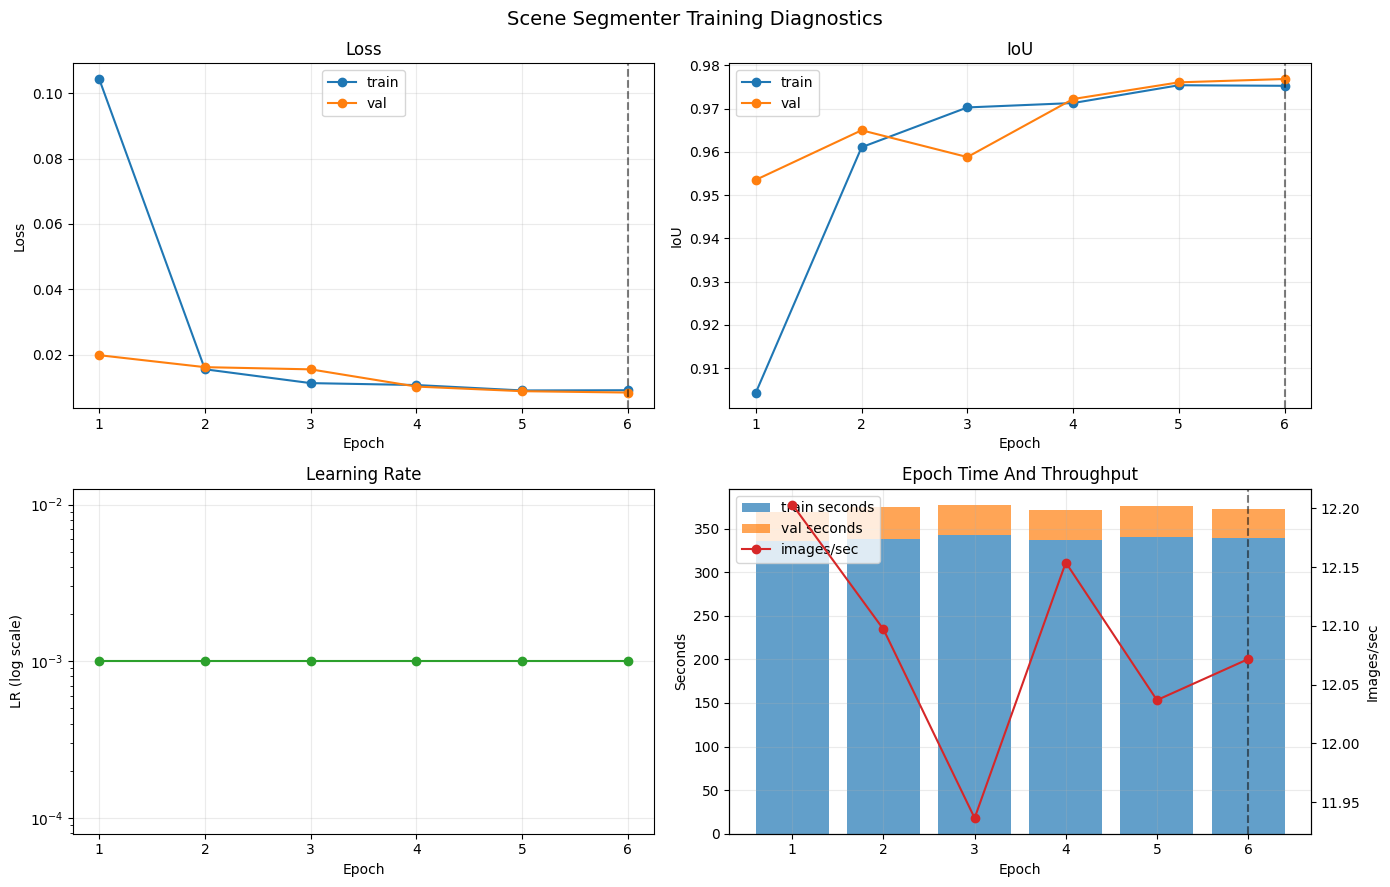

Best epoch: 6
Best val IoU: 0.9768
Epoch time at best epoch: 372.98s
Mean throughput: 12.08 img/s


In [4]:
plot_training_curves(state)

## Qualitative predictions on validation

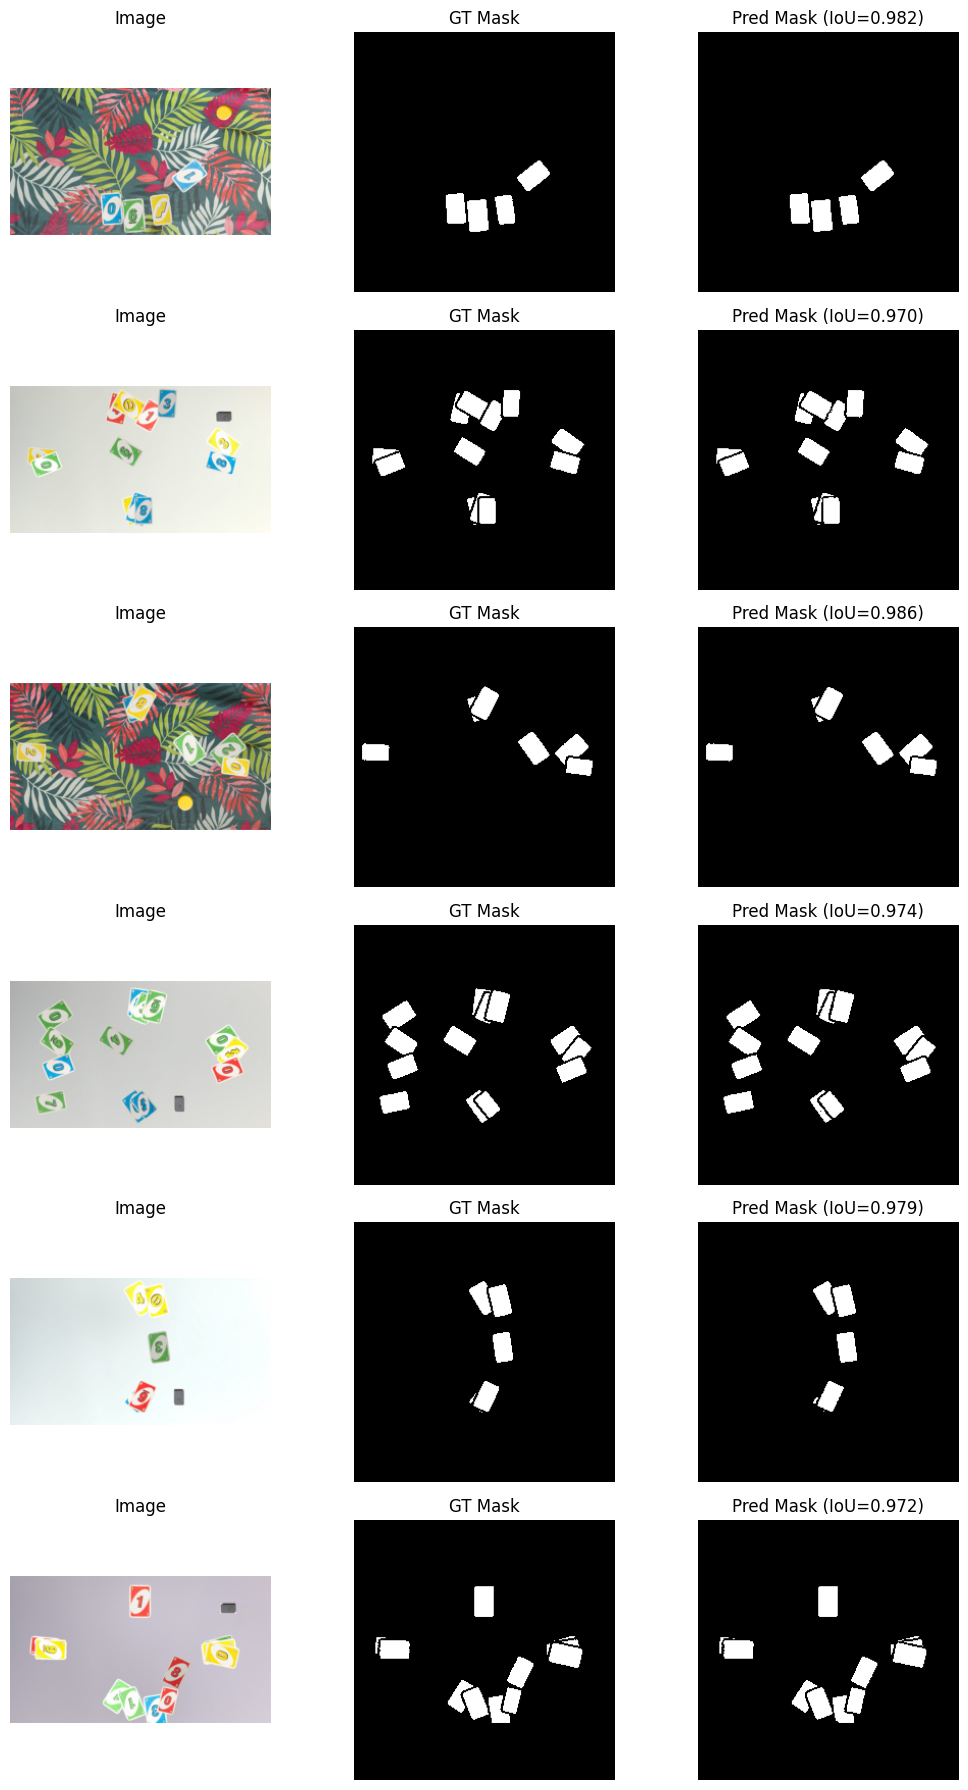

In [5]:
plot_segmentation_predictions(state, num_show=CFG.preview_count)